In [3]:
import joblib
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- PARÁMETROS ---
# Asegúrate de que esta lista sea la misma que usaste para entrenar el modelo
# Si usaste las características avanzadas, inclúyelas aquí.
FEATURES = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']
TARGET = 'class'
MODEL_FILE = 'deforestation_model_v3_temporal.pkl' # El nombre del archivo que guardaste
TEST_DATA_FILE = 'testing_samples.csv'

# --- CARGAR ARTEFACTOS ---
print(f"Cargando el modelo desde '{MODEL_FILE}'...")
loaded_classifier = joblib.load(MODEL_FILE)

print(f"Cargando datos de prueba desde '{TEST_DATA_FILE}'...")
test_df = pd.read_csv(TEST_DATA_FILE)

# Preparamos los datos de la misma forma que en el entrenamiento
X_test_new = test_df[FEATURES]
y_test_true = test_df[TARGET]

print("¡Modelo y datos cargados exitosamente!")

Cargando el modelo desde 'deforestation_model_v3_temporal.pkl'...
Cargando datos de prueba desde 'testing_samples.csv'...
¡Modelo y datos cargados exitosamente!


In [5]:
# --- REALIZAR PREDICCIONES ---
print("\nRealizando predicciones sobre los datos de prueba...")
y_predictions = loaded_classifier.predict(X_test_new)

# Creamos un DataFrame para comparar fácilmente los resultados
results_df = pd.DataFrame({
    'Clase Real': y_test_true,
    'Clase Predicha': y_predictions
})

print("Primeras 10 predicciones:")
print(results_df.head(60))


Realizando predicciones sobre los datos de prueba...
Primeras 10 predicciones:
    Clase Real  Clase Predicha
0            0               0
1            0               0
2            0               0
3            0               0
4            0               0
5            0               0
6            0               0
7            0               0
8            0               0
9            0               0
10           0               0
11           0               0
12           0               2
13           0               0
14           0               0
15           0               0
16           0               0
17           0               0
18           0               0
19           0               0
20           0               2
21           0               0
22           0               0
23           0               0
24           0               0
25           0               2
26           0               0
27           0               0
28           0       


Evaluando las predicciones del modelo cargado...

Reporte de Clasificación:
                   precision    recall  f1-score   support

Otras Tierras (0)       0.71      0.83      0.76       428
       Bosque (1)       0.60      0.53      0.56       443
  Deforestado (2)       0.55      0.53      0.54       432

         accuracy                           0.63      1303
        macro avg       0.62      0.63      0.62      1303
     weighted avg       0.62      0.63      0.62      1303



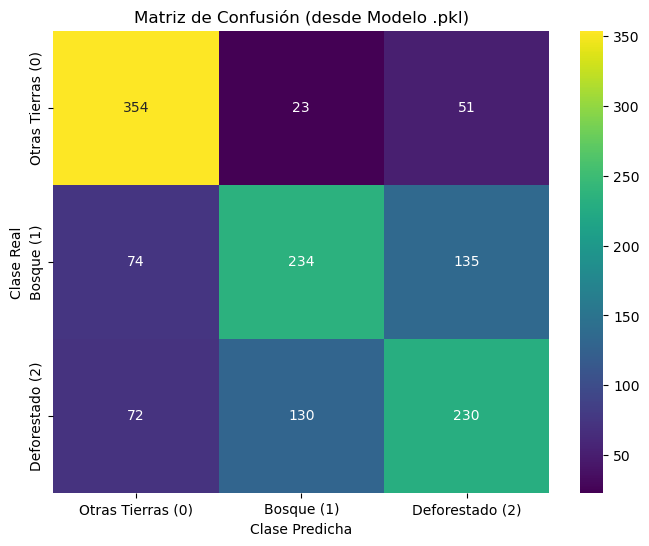


¡Proceso completado!


In [6]:
# --- VISUALIZAR LOS RESULTADOS ---
print("\nEvaluando las predicciones del modelo cargado...")

# Generar el reporte de clasificación
class_labels = ['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)']
report = classification_report(y_test_true, y_predictions, target_names=class_labels)
print("\nReporte de Clasificación:")
print(report)

# Generar la matriz de confusión
cm = confusion_matrix(y_test_true, y_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión (desde Modelo .pkl)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

print("\n¡Proceso completado!")